In [1]:
!pip install transformers datasets evaluate rouge_score torch pandas numpy matplotlib seaborn

In [2]:
import os

os.environ["HF_HOME"] = "D:/huggingface_cache"
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

import time
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from datasets import load_dataset
import evaluate

sns.set_theme(style="whitegrid")
%matplotlib inline

In [3]:
dataset = load_dataset("cnn_dailymail", "3.0.0", split="test[:10]")

texts = dataset["article"]
references = dataset["highlights"]

In [4]:
model_names = [
    "sshleifer/distilbart-cnn-12-6",
    "t5-small",
    "google/flan-t5-small",
    "facebook/bart-base"
]

rouge = evaluate.load("rouge")

In [5]:
results_data = []

for model_name in model_names:
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
    
    model_params = model.num_parameters()
    
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    
    generated_summaries = []
    start_time = time.time()
    
    for text in texts:
        input_text = "summarize: " + text if "t5" in model_name else text
        
        inputs = tokenizer(input_text, return_tensors="pt", max_length=1024, truncation=True).to(device)
        
        with torch.no_grad():
            summary_ids = model.generate(inputs["input_ids"], max_length=150, min_length=40, length_penalty=2.0, num_beams=4, early_stopping=True)
        
        summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
        generated_summaries.append(summary)
        
    end_time = time.time()
    total_inference_time = end_time - start_time
    
    scores = rouge.compute(predictions=generated_summaries, references=references)
    
    results_data.append({
        "Model": model_name,
        "ROUGE-1": scores['rouge1'],
        "ROUGE-2": scores['rouge2'],
        "ROUGE-L": scores['rougeL'],
        "Inference Time (s)": total_inference_time,
        "Model Size (Params)": model_params
    })
    
    del model
    del tokenizer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

df_results = pd.DataFrame(results_data)
display(df_results)

Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

config.json: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

,Model,ROUGE-1,ROUGE-2,ROUGE-L,Inference Time (s),Model Size (Params)
0,sshleifer/distilbart-cnn-12-6,0.398013,0.186944,0.302741,26.412706,408451072
1,t5-small,0.378294,0.144781,0.258894,13.205745,60506624
2,google/flan-t5-small,0.322406,0.126095,0.251221,13.126263,76961152
3,facebook/bart-base,0.291799,0.123109,0.200613,42.676836,139420416


In [6]:
def apply_topsis(df):
    cols = ["ROUGE-1", "ROUGE-2", "ROUGE-L", "Inference Time (s)", "Model Size (Params)"]
    matrix = df[cols].values
    
    rss = np.sqrt(np.sum(matrix**2, axis=0))
    normalized_matrix = matrix / rss
    
    weights = np.array([0.25, 0.25, 0.25, 0.15, 0.10]) 
    impacts = np.array(['+', '+', '+', '-', '-'])
    
    weighted_matrix = normalized_matrix * weights
    
    ideal_best = []
    ideal_worst = []
    
    for i in range(len(cols)):
        if impacts[i] == '+':
            ideal_best.append(np.max(weighted_matrix[:, i]))
            ideal_worst.append(np.min(weighted_matrix[:, i]))
        else:
            ideal_best.append(np.min(weighted_matrix[:, i]))
            ideal_worst.append(np.max(weighted_matrix[:, i]))
            
    ideal_best = np.array(ideal_best)
    ideal_worst = np.array(ideal_worst)
    
    dist_best = np.sqrt(np.sum((weighted_matrix - ideal_best)**2, axis=1))
    dist_worst = np.sqrt(np.sum((weighted_matrix - ideal_worst)**2, axis=1))
    
    topsis_score = dist_worst / (dist_best + dist_worst)
    
    return topsis_score

df_results["TOPSIS Score"] = apply_topsis(df_results)
df_results["Rank"] = df_results["TOPSIS Score"].rank(ascending=False).astype(int)

df_final = df_results.sort_values(by="Rank")
display(df_final)

,Model,ROUGE-1,ROUGE-2,ROUGE-L,Inference Time (s),Model Size (Params),TOPSIS Score,Rank
1,t5-small,0.378294,0.144781,0.258894,13.205745,60506624,0.744119,1
2,google/flan-t5-small,0.322406,0.126095,0.251221,13.126263,76961152,0.643962,2
0,sshleifer/distilbart-cnn-12-6,0.398013,0.186944,0.302741,26.412706,408451072,0.520688,3
3,facebook/bart-base,0.291799,0.123109,0.200613,42.676836,139420416,0.339177,4


C:\Users\HP\AppData\Local\Temp\ipykernel_21388\1850270962.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="TOPSIS Score", y="Model", data=df_final, palette="viridis")


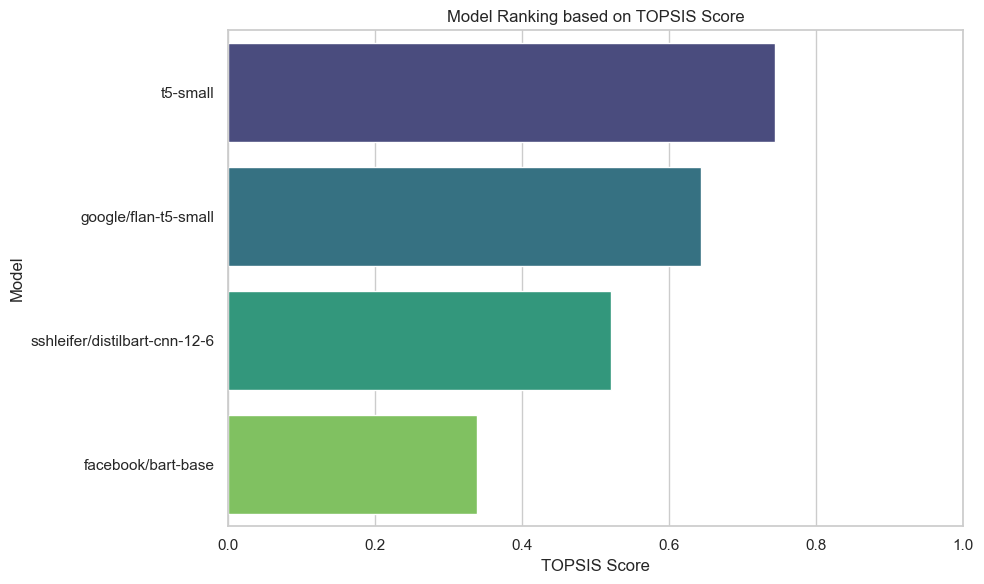

In [7]:
plt.figure(figsize=(10, 6))
sns.barplot(x="TOPSIS Score", y="Model", data=df_final, palette="viridis")
plt.title("Model Ranking based on TOPSIS Score")
plt.xlabel("TOPSIS Score")
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig("model_ranking_graph.png")
plt.show()

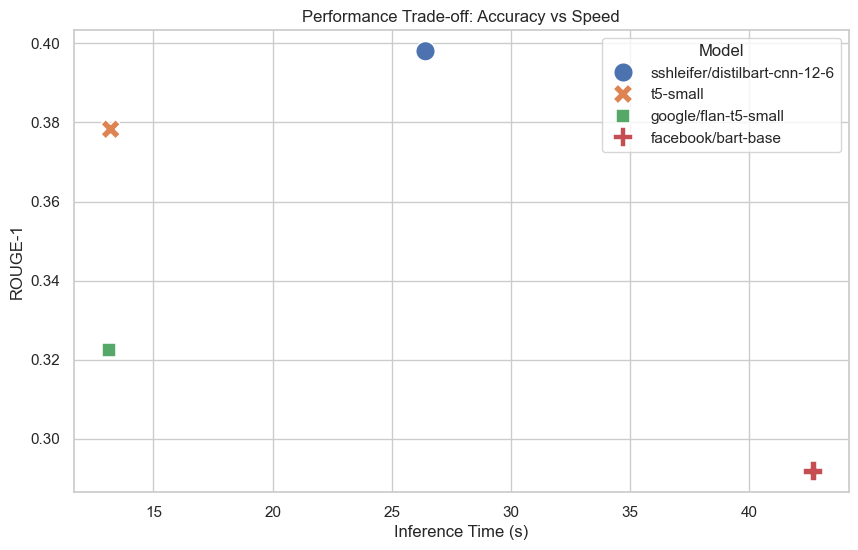

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_results, x="Inference Time (s)", y="ROUGE-1", hue="Model", s=200, style="Model")
plt.title("Performance Trade-off: Accuracy vs Speed")
plt.grid(True)
plt.savefig("tradeoff_graph.png")
plt.show()

In [9]:
df_final.to_csv("topsis_results.csv", index=False)